# INDR 422/522 Term Project
## Daily Natural Gas Demand Prediction and Stock Prescriptive Analysis for South East England Local Distribution Zone (SE LDZ)

In [1]:
%pip install pandas matplotlib numpy scipy seaborn gurobipy statsmodels scikit-learn xgboost bbplot torch tensorflow shap


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import KFold, GridSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from xgboost import XGBRegressor
import shap
from scipy import stats
from gurobipy import *
from bbplot import bijan
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

/Users/smak/COURSES/INDR422/project/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
### Part 0: Data Loading & Exploratory Overview

In [3]:
data = pd.read_csv('data/dataset.csv', index_col=0, parse_dates=['date']).set_index('date')

bool_cols = data.select_dtypes(bool).columns.tolist()
data[bool_cols] = data[bool_cols].astype(int)

FEATURE_COLS = [c for c in data.columns if c not in ('demand', 'dow', 'month')]
TARGET = 'demand'

dow_dummies = [f'dow_{i}' for i in range(1, 7)]
month_dummies = [f'month_{i}' for i in range(2, 13)]
FEATURE_COLS_TREE = [c for c in data.columns if c not in dow_dummies + month_dummies + ['demand']]

split = -365
train = data.iloc[:split].copy()
test = data.iloc[split:].copy()

X_train = train[FEATURE_COLS].values.astype(float)
y_train = train[TARGET].values.astype(float)
X_test = test[FEATURE_COLS].values.astype(float)
y_test = test[TARGET].values.astype(float)

X_train_tree = train[FEATURE_COLS_TREE].values.astype(float)
X_test_tree = test[FEATURE_COLS_TREE].values.astype(float)

print(f'Training: {len(train)} samples ({train.index[0].date()} to {train.index[-1].date()})')
print(f'Test: {len(test)} samples ({test.index[0].date()} to {test.index[-1].date()})')
print(f'Features (linear models): {len(FEATURE_COLS)}')
print(f'Features (tree models): {len(FEATURE_COLS_TREE)}')
data.describe()

Training: 1448 samples (2021-05-24 to 2025-05-10)
Test: 365 samples (2025-05-11 to 2026-05-10)
Features (linear models): 26
Features (tree models): 11


,demand,precipitation_mm,wind_kmh,temp_c,is_holiday,demand_lag1,demand_lag7,demand_lag14,dow,dow_1,...,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12,hdd,time_trend
count,1813.000000,1813.000000,1813.000000,1813.000000,1813.000000,1813.000000,1813.000000,1813.000000,1813.000000,1813.000000,...,1813.000000,1813.000000,1813.000000,1813.000000,1813.000000,1813.000000,1813.000000,1813.000000,1813.000000,1813.000000
mean,11.315601,2.047711,20.144126,11.917540,0.014892,11.317957,11.331738,11.345826,4.000000,0.142857,...,0.078323,0.082736,0.085494,0.085494,0.082736,0.085494,0.082736,0.085494,4.452344,920.000000
std,6.794403,4.068300,7.811439,5.524973,0.121156,6.794451,6.793396,6.790309,2.000552,0.350024,...,0.268754,0.275558,0.279692,0.279692,0.275558,0.279692,0.275558,0.279692,4.407522,523.512337
min,0.608830,0.000000,3.500000,-3.000000,0.000000,0.608830,0.608830,0.608830,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000
25%,5.689590,0.000000,14.200000,8.100000,0.000000,5.689590,5.689590,5.689590,2.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,467.000000
50%,9.823720,0.300000,19.000000,11.900000,0.000000,9.828730,9.896020,9.968520,4.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.600000,920.000000
75%,16.313480,2.300000,24.800000,16.200000,0.000000,16.313480,16.313480,16.313480,6.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.400000,1373.000000
max,30.763630,48.700000,68.000000,29.100000,1.000000,30.763630,30.763630,30.763630,7.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,18.500000,1826.000000


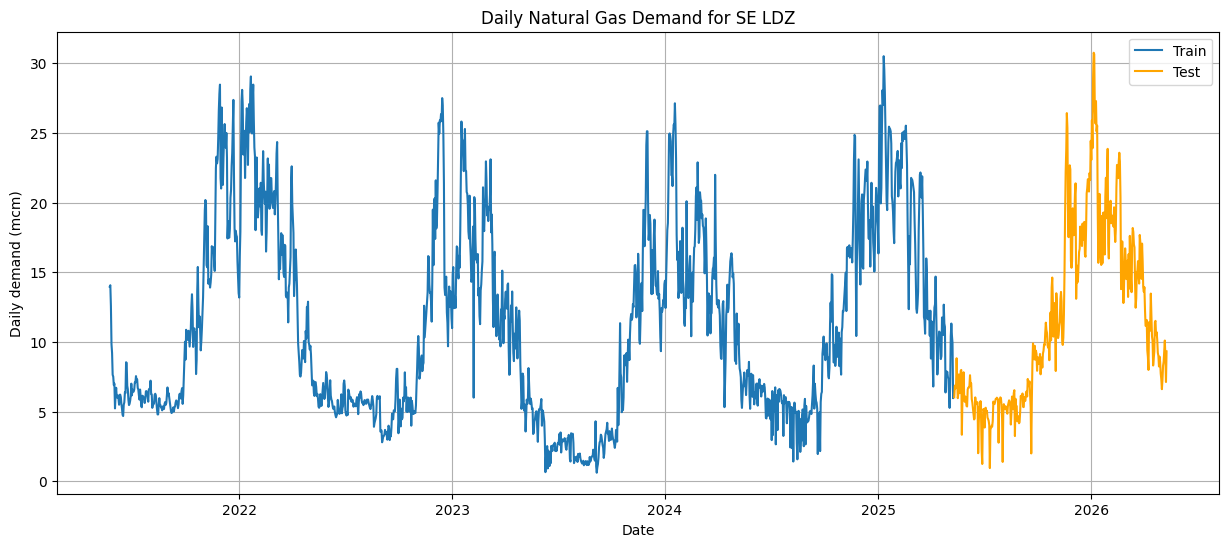

In [ ]:
plt.figure(figsize=(15, 6))
plt.plot(train.index, train[TARGET], label='Train')
plt.plot(test.index, test[TARGET], label='Test', color='orange')
plt.xlabel('Date')
plt.ylabel('Daily demand (mscm)')
plt.title('Daily Natural Gas Demand for SE LDZ')
plt.legend()
plt.grid(True)
plt.show()

## Part 1: Evaluation Utilities

Helper functions and shared storage used by every model section.

In [5]:
results = {}
predictions = {}


def evaluate(y_true, y_pred, name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    results[name] = {'RMSE': rmse, 'MAE': mae, 'MAPE (%)': mape}
    print(f'RMSE = {rmse:.4f}')
    print(f'MAE  = {mae:.4f}')
    print(f'MAPE = {mape:.2f}%')
    return rmse, mae, mape


def plot_forecast(y_true, y_pred, title):
    plt.figure(figsize=(15, 6))
    plt.plot(test.index, y_true, label='Actual')
    plt.plot(test.index, y_pred, label='Predicted', alpha=0.85)
    plt.xlabel('Date')
    plt.ylabel('Demand')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


def mismatch_cost(q, d, cu=None, co=None):
    q = np.asarray(q, dtype=float)
    d = np.asarray(d, dtype=float)
    return co * np.maximum(q - d, 0) + cu * np.maximum(d - q, 0)


def average_cost(q, d, cu=None, co=None):
    return float(np.mean(mismatch_cost(q, d, cu=cu, co=co)))


def empirical_quantile_min_cdf(values, alpha):
    values = np.asarray(values, dtype=float)
    sorted_vals = np.sort(values)
    k = max(int(np.ceil(alpha * len(sorted_vals))), 1)
    return float(sorted_vals[k - 1])

---
## Part 2: OLS Linear Regression

Baseline linear model using all features. `statsmodels` is used to obtain the full coefficient table and statistical summaries.

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 demand   R-squared:                       0.962
Model:                            OLS   Adj. R-squared:                  0.961
Method:                 Least Squares   F-statistic:                     1386.
Date:                Sun, 07 Jun 2026   Prob (F-statistic):               0.00
Time:                        14:47:23   Log-Likelihood:                -2483.9
No. Observations:                1448   AIC:                             5022.
Df Residuals:                    1421   BIC:                             5164.
Df Model:                          26                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            1.8182      0.624      2.914      0.004       0.594       3.042
precipitation_mm     0.0131      0.009      1.430      0.153      -0.005       0.031
wind_kmh            -0.0021      0.005     -0.431      0.666      -0.012       0.008
temp_c              -0.0024      0.028     -0.085      0.933      -0.058       0.053
is_holiday          -0.2413      0.306     -0.789      0.430      -0.841       0.359
demand_lag1          0.5565      0.016     35.369      0.000       0.526       0.587
demand_lag7          0.0628      0.013      4.756      0.000       0.037       0.089
demand_lag14         0.0627      0.012      5.164      0.000       0.039       0.087
dow_1               -0.3079      0.135     -2.288      0.022      -0.572      -0.044
dow_2               -0.2131      0.135     -1.582      0.114      -0.477       0.051
dow_3               -0.2737      0.135     -2.029      0.043      -0.538      -0.009
dow_4               -0.2654      0.135     -1.966      0.050      -0.530      -0.001
dow_5               -0.8419      0.136     -6.200      0.000      -1.108      -0.576
dow_6               -0.4296      0.135     -3.172      0.002      -0.695      -0.164
month_2             -0.1805      0.182     -0.991      0.322      -0.538       0.177
month_3             -0.5617      0.185     -3.036      0.002      -0.925      -0.199
month_4             -0.7757      0.216     -3.584      0.000      -1.200      -0.351
month_5             -0.5057      0.264     -1.917      0.055      -1.023       0.012
month_6             -0.0845      0.295     -0.286      0.775      -0.664       0.495
month_7              0.2950      0.306      0.966      0.334      -0.304       0.894
month_8             -0.0108      0.310     -0.035      0.972      -0.619       0.598
month_9             -0.1651      0.304     -0.543      0.587      -0.762       0.432
month_10            -0.0603      0.264     -0.228      0.819      -0.578       0.457
month_11             0.3017      0.207      1.459      0.145      -0.104       0.707
month_12            -0.3384      0.176     -1.922      0.055      -0.684       0.007
hdd                  0.5397      0.036     14.987      0.000       0.469       0.610
time_trend          -0.0002   8.97e-05     -2.530      0.012      -0.000    -5.1e-05
==============================================================================
Omnibus:                      487.576   Durbin-Watson:                   1.684
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            11400.433
Skew:                          -1.013   Prob(JB):                         0.00
Kurtosis:                      16.596   Cond. No.                     1.97e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matr


=== OLS TEST PERFORMANCE ===
RMSE = 1.3694
MAE  = 1.1141
MAPE = 13.29%


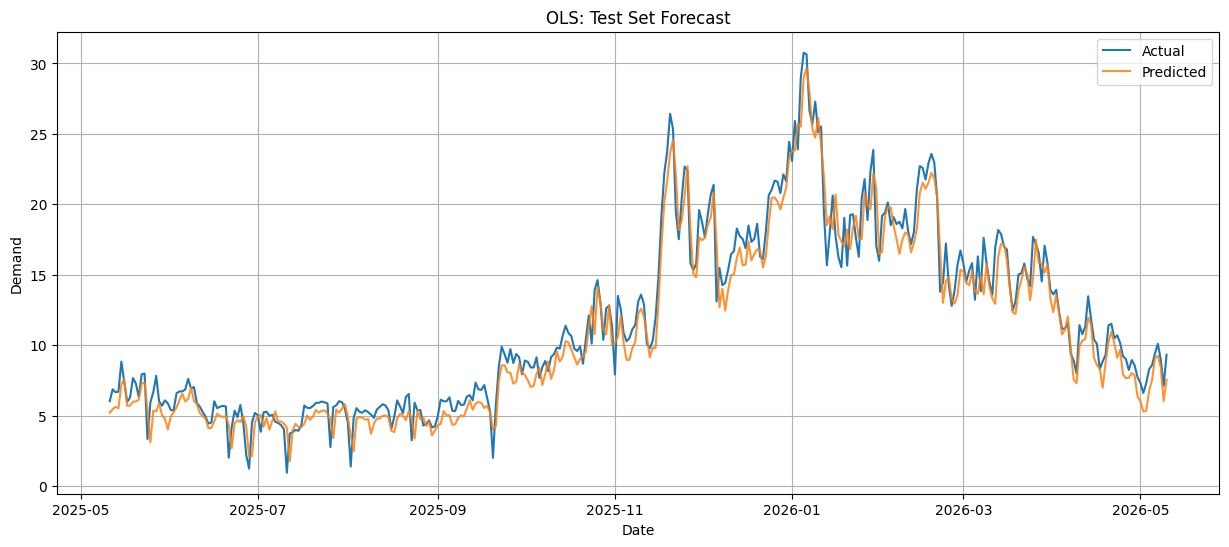

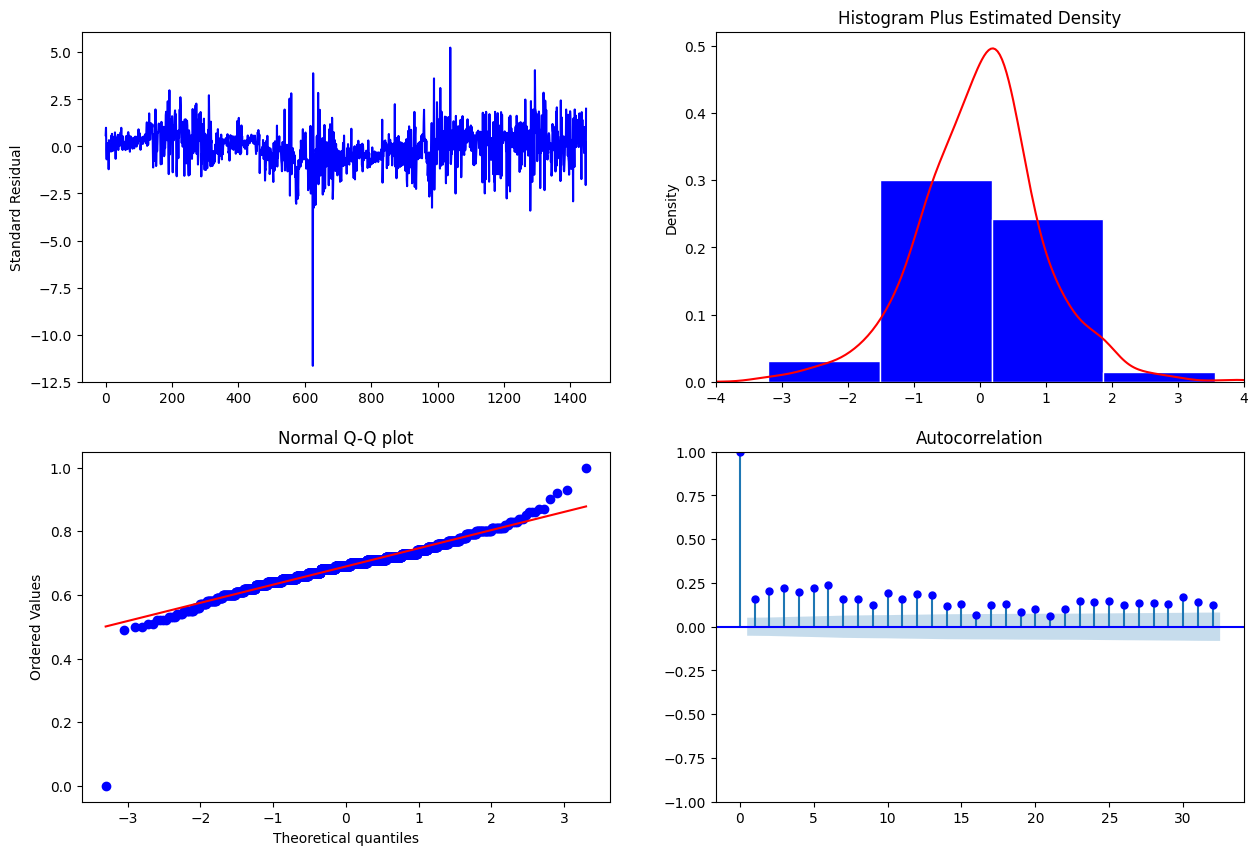

In [6]:
formula = 'demand ~ ' + ' + '.join(FEATURE_COLS)
ols_fit = smf.ols(formula=formula, data=train).fit()
display(ols_fit.summary())

y_pred_train_ols = ols_fit.predict(train).values
y_pred_test_ols = ols_fit.predict(test).values
predictions['OLS'] = {'train': y_pred_train_ols, 'test': y_pred_test_ols}

print('\n=== OLS TEST PERFORMANCE ===')
evaluate(y_test, y_pred_test_ols, 'OLS')
plot_forecast(y_test, y_pred_test_ols, 'OLS: Test Set Forecast')

resid_ols = y_train - y_pred_train_ols
bijan.eplot(resid_ols)

---
## Part 3: Ridge and Lasso Regression

Regularised linear models. Both use 5-fold cross-validation to select the regularisation strength α. Features are standardised inside a `Pipeline`.

Ridge (alpha = 0.1000)
=== Ridge TEST PERFORMANCE ===
RMSE = 1.3694
MAE  = 1.1143
MAPE = 13.29%


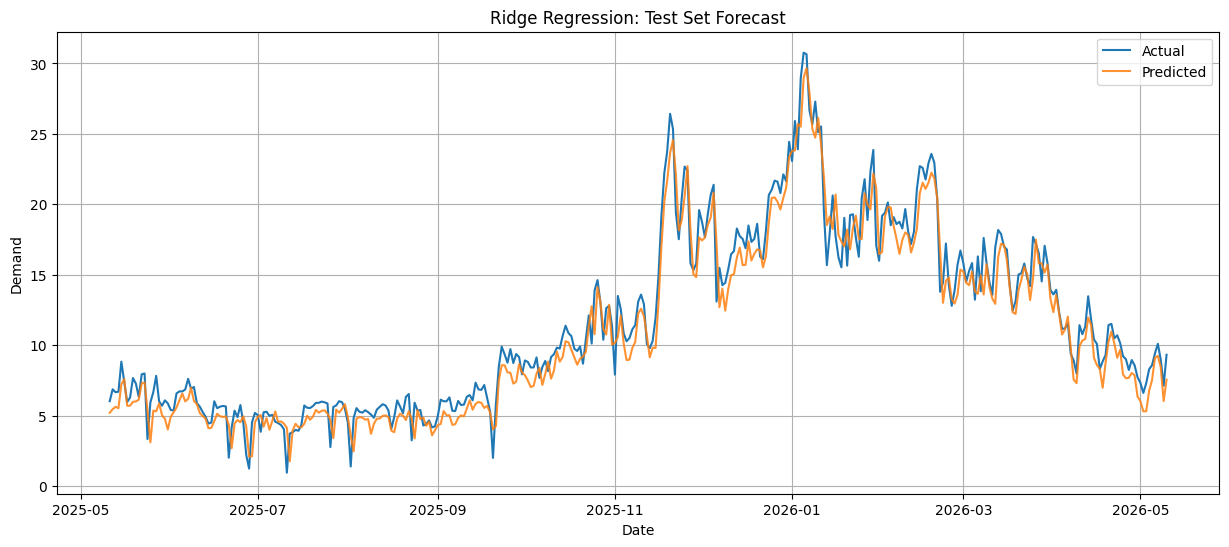

Lasso (alpha = 0.2512, # non-zero coefficients = 4)
=== Lasso TEST PERFORMANCE ===
RMSE = 1.3617
MAE  = 1.0187
MAPE = 12.32%


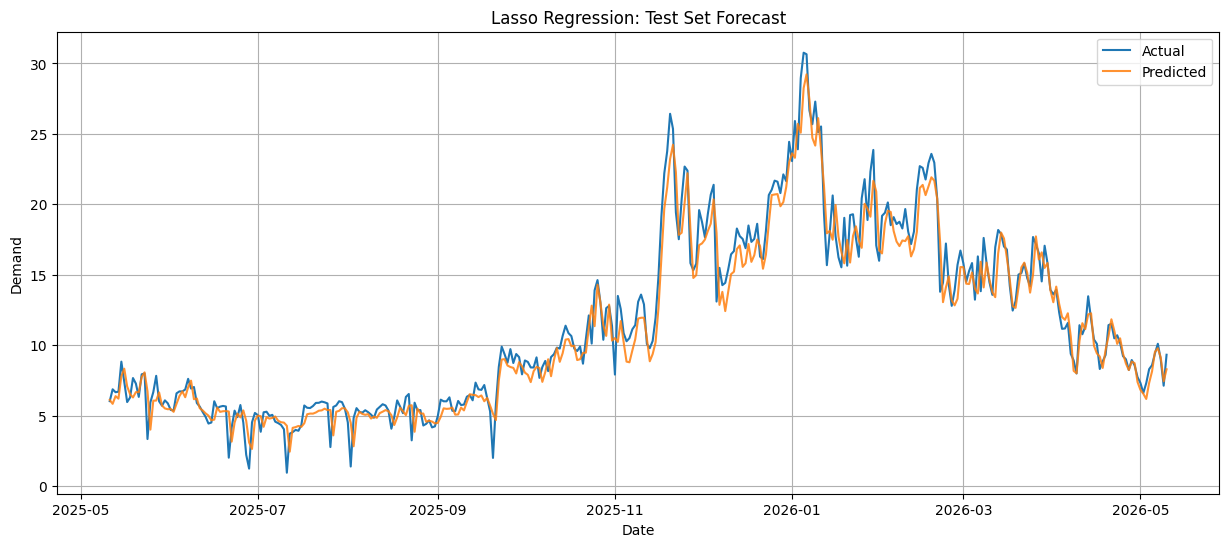

In [7]:
ridge = Pipeline([('scaler', StandardScaler()), ('model', RidgeCV(cv=5))])
ridge.fit(X_train, y_train)
y_pred_train_ridge = ridge.predict(X_train)
y_pred_test_ridge = ridge.predict(X_test)
predictions['Ridge'] = {'train': y_pred_train_ridge, 'test': y_pred_test_ridge}

print(f'Ridge (alpha = {ridge.named_steps["model"].alpha_:.4f})')
print('=== Ridge TEST PERFORMANCE ===')
evaluate(y_test, y_pred_test_ridge, 'Ridge')
plot_forecast(y_test, y_pred_test_ridge, 'Ridge Regression: Test Set Forecast')


lasso = Pipeline([('scaler', StandardScaler()), ('model', LassoCV(cv=5, max_iter=10000))])
lasso.fit(X_train, y_train)
y_pred_train_lasso = lasso.predict(X_train)
y_pred_test_lasso = lasso.predict(X_test)
predictions['Lasso'] = {'train': y_pred_train_lasso, 'test': y_pred_test_lasso}

coef = lasso.named_steps['model'].coef_
print(f'Lasso (alpha = {lasso.named_steps["model"].alpha_:.4f}, # non-zero coefficients = {np.sum(coef != 0)})')
print('=== Lasso TEST PERFORMANCE ===')
evaluate(y_test, y_pred_test_lasso, 'Lasso')
plot_forecast(y_test, y_pred_test_lasso, 'Lasso Regression: Test Set Forecast')

---
## Part 4: k-NN Regression

Non-parametric kernel-style method. The number of neighbours *k* is chosen by 5-fold cross-validation over k = 1 … 30.

Best k = 36  (CV RMSE = 2.3347)


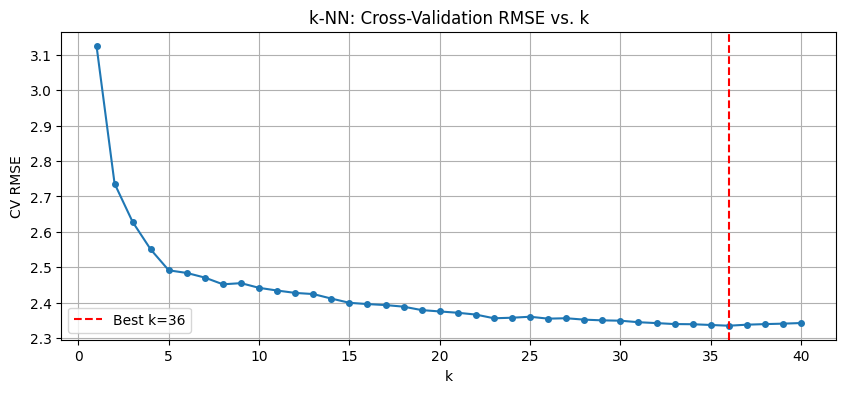


=== k-NN (k=36) TEST PERFORMANCE ===
RMSE = 1.6575
MAE  = 1.2280
MAPE = 14.73%


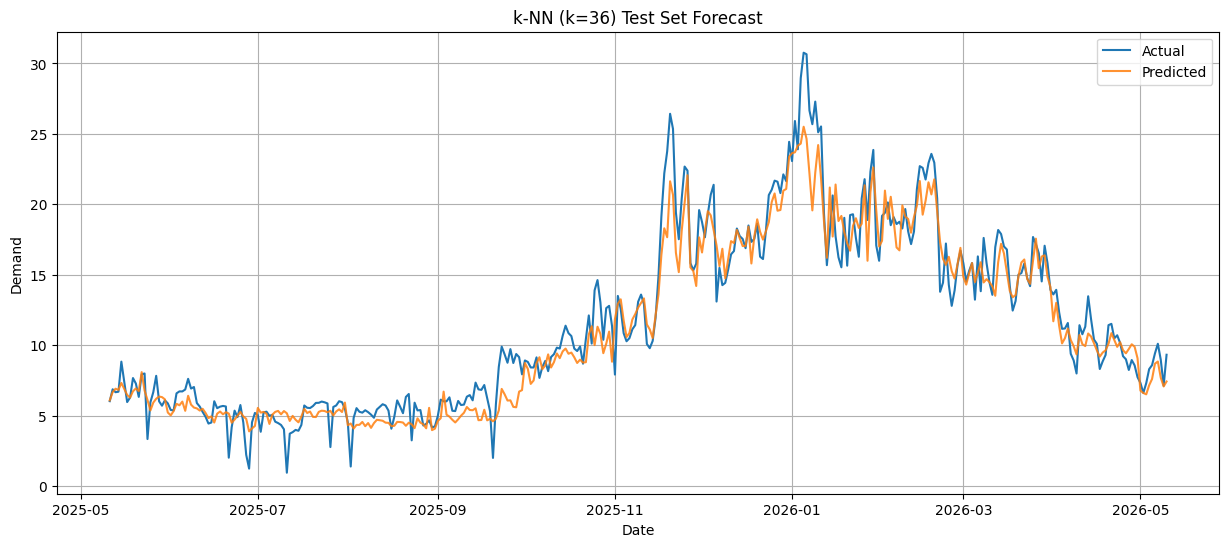

In [8]:
kf = KFold(n_splits=5, shuffle=False)
k_values = range(1, 41)
cv_rmse = []
for k in k_values:
    pipe = Pipeline([('scaler', RobustScaler()),
                     ('model', KNeighborsRegressor(n_neighbors=k, p=1))])
    scores = cross_val_score(
        pipe, X_train, y_train, cv=kf, scoring='neg_mean_squared_error'
    )
    cv_rmse.append(np.sqrt(-scores.mean()))

best_k = list(k_values)[np.argmin(cv_rmse)]
print(f'Best k = {best_k}  (CV RMSE = {min(cv_rmse):.4f})')

plt.figure(figsize=(10, 4))
plt.plot(list(k_values), cv_rmse, marker='o', markersize=4)
plt.axvline(best_k, color='red', linestyle='--', label=f'Best k={best_k}')
plt.xlabel('k')
plt.ylabel('CV RMSE')
plt.title('k-NN: Cross-Validation RMSE vs. k')
plt.legend()
plt.grid(True)
plt.show()

knn_best = Pipeline([('scaler', RobustScaler()),
                     ('model', KNeighborsRegressor(n_neighbors=best_k, p=1))])
knn_best.fit(X_train, y_train)
y_pred_train_knn = knn_best.predict(X_train)
y_pred_test_knn = knn_best.predict(X_test)
predictions['kNN'] = {'train': y_pred_train_knn, 'test': y_pred_test_knn}
print(f'\n=== k-NN (k={best_k}) TEST PERFORMANCE ===')
evaluate(y_test, y_pred_test_knn, 'kNN')
plot_forecast(y_test, y_pred_test_knn, f'k-NN (k={best_k}) Test Set Forecast')

---
## Part 5: SARIMAX

Seasonal ARIMA with exogenous regressors. Weather, calendar, and lag features are passed as exogenous variables. A grid over both ARIMA and seasonal orders is evaluated by AIC on the training set.

The residual ACF shows significant autocorrelation at lags 1–6, which is characteristic of a weekly seasonal pattern (s=7). Seasonal ARIMA orders (P, D, Q) with s=7 are therefore included in the search.

Yearly seasonality (s=365) is not modelled here: with daily data the seasonal difference operator would introduce 365 lags, making estimation extremely slow and numerically unstable. Annual patterns are already captured by the exogenous features (HDD, month dummies, time trend), so a separate s=365 ARIMA term would be redundant.

SARIMA(1, 0, 0)x(0, 0, 0, 7): AIC = 4980.99
SARIMA(1, 0, 0)x(1, 0, 0, 7): AIC = 4993.01
SARIMA(1, 0, 0)x(0, 0, 1, 7): AIC = 4951.87
SARIMA(1, 0, 0)x(1, 0, 1, 7): AIC = 4882.83
SARIMA(1, 0, 0)x(1, 1, 0, 7): AIC = 5011.93
SARIMA(1, 0, 0)x(1, 1, 1, 7): AIC = 4710.22
SARIMA(1, 0, 1)x(0, 0, 0, 7): AIC = 5041.87
SARIMA(1, 0, 1)x(1, 0, 0, 7): AIC = 5008.90
SARIMA(1, 0, 1)x(0, 0, 1, 7): AIC = 5023.85
SARIMA(1, 0, 1)x(1, 0, 1, 7): AIC = 4995.44
SARIMA(1, 0, 1)x(1, 1, 0, 7): AIC = 5000.52
SARIMA(1, 0, 1)x(1, 1, 1, 7): AIC = 4683.40
SARIMA(0, 0, 1)x(0, 0, 0, 7): AIC = 5010.04
SARIMA(0, 0, 1)x(1, 0, 0, 7): AIC = 4968.89
SARIMA(0, 0, 1)x(0, 0, 1, 7): AIC = 4998.39
SARIMA(0, 0, 1)x(1, 0, 1, 7): AIC = 4979.27
SARIMA(0, 0, 1)x(1, 1, 0, 7): AIC = 5012.29
SARIMA(0, 0, 1)x(1, 1, 1, 7): AIC = 4716.00

Best order: SARIMA(1, 0, 1)x(1, 1, 1, 7)

=== SARIMA(1, 0, 1)x(1, 1, 1, 7) TEST PERFORMANCE ===
RMSE = 1.4377
MAE  = 1.1419
MAPE = 13.16%


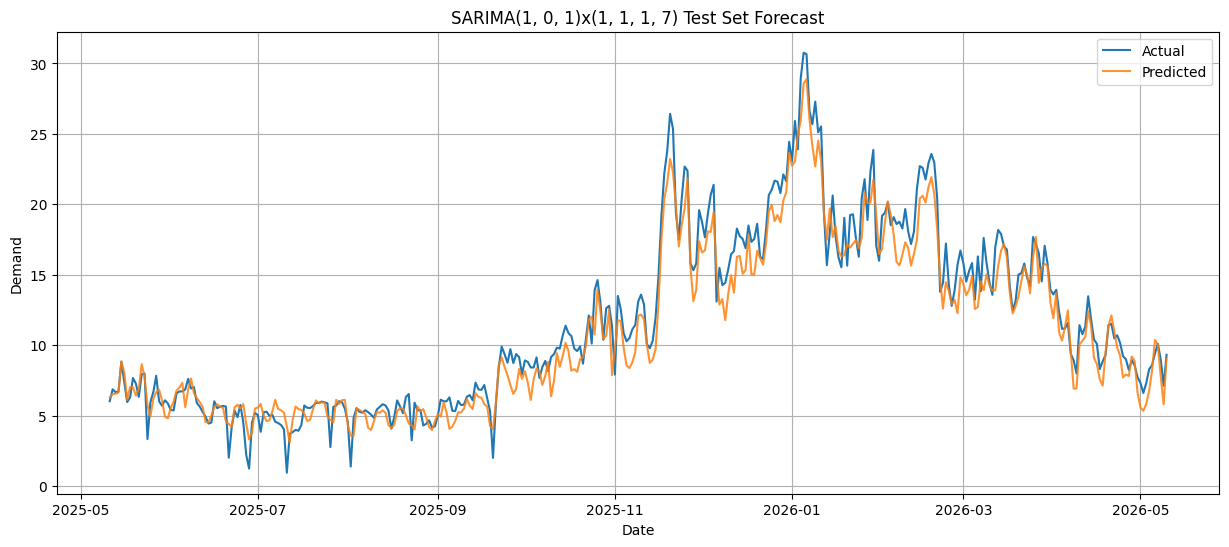

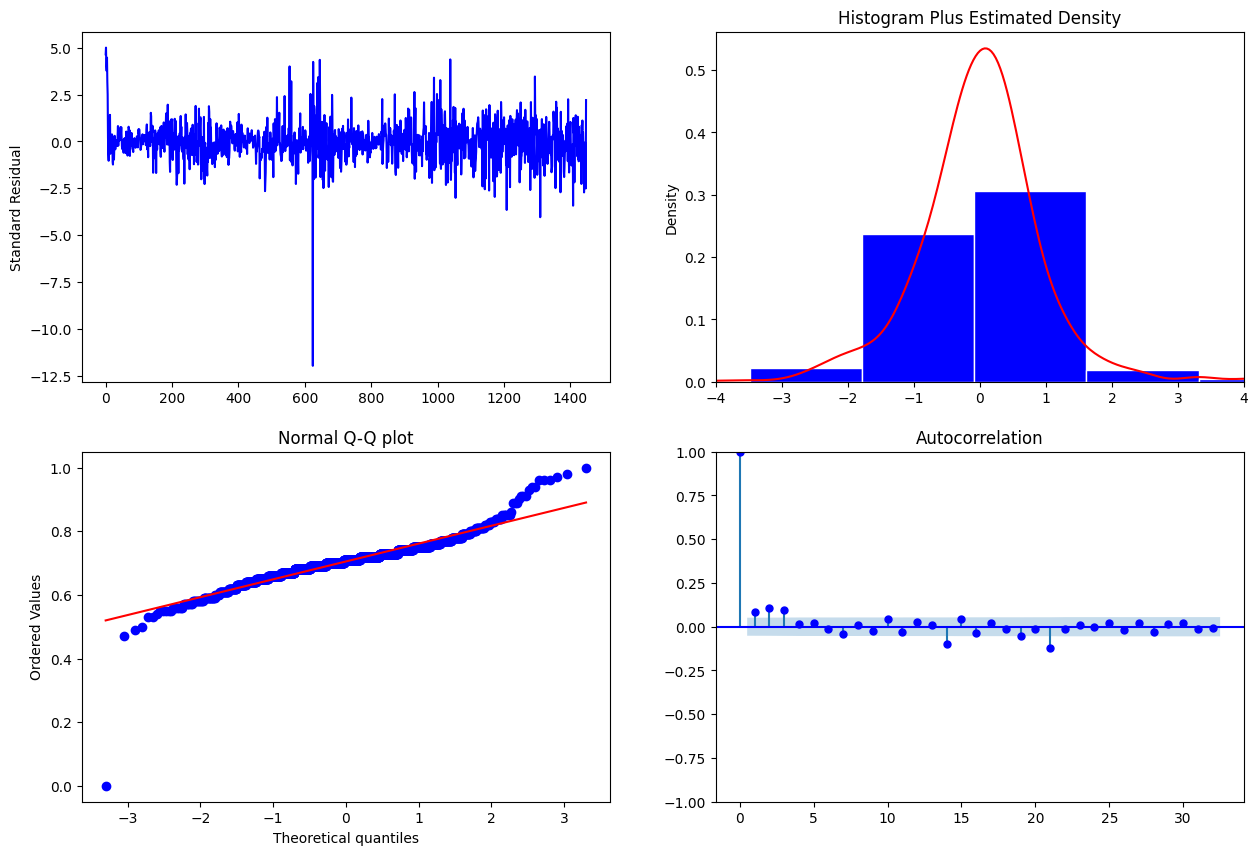

In [9]:
arima_orders = [(1, 0, 0), (1, 0, 1), (0, 0, 1)]
seasonal_orders = [(0, 0, 0, 7), (1, 0, 0, 7), (0, 0, 1, 7), (1, 0, 1, 7), (1, 1, 0, 7), (1, 1, 1, 7)]

aic_scores = {}
for order in arima_orders:
    for s_order in seasonal_orders:
        key = (order, s_order)
        try:
            res = SARIMAX(y_train, exog=X_train, order=order,
                          seasonal_order=s_order, trend='c').fit(disp=False)
            aic_scores[key] = res.aic
            print(f'SARIMA{order}x{s_order}: AIC = {res.aic:.2f}')
        except Exception as e:
            print(f'SARIMA{order}x{s_order}: failed ({e})')

best_key = min(aic_scores, key=aic_scores.get)
best_order, best_s_order = best_key
print(f'\nBest order: SARIMA{best_order}x{best_s_order}')

sarimax_fit = SARIMAX(y_train, exog=X_train, order=best_order,
                      seasonal_order=best_s_order, trend='c').fit(disp=False)

y_pred_train_sarimax = sarimax_fit.fittedvalues
forecast_obj = sarimax_fit.get_forecast(steps=len(y_test), exog=X_test)
y_pred_test_sarimax = forecast_obj.predicted_mean

predictions['SARIMAX'] = {'train': y_pred_train_sarimax, 'test': y_pred_test_sarimax}
print(f'\n=== SARIMA{best_order}x{best_s_order} TEST PERFORMANCE ===')
evaluate(y_test, y_pred_test_sarimax, 'SARIMAX')
plot_forecast(y_test, y_pred_test_sarimax, f'SARIMA{best_order}x{best_s_order} Test Set Forecast')

bijan.eplot(sarimax_fit.resid)

---
## Part 6: Decision Tree Regression

Non-parametric tree-based model. Maximum depth is tuned via 5-fold cross-validation.

Uses `FEATURE_COLS_TREE`: raw integer `dow` and `month` replace the one-hot dummies. Tree splits on thresholds (e.g. `dow ≤ 4`) can recover the same categorical distinctions with fewer features and cleaner importance scores.

Best depth = 5  (CV RMSE = 1.7409)


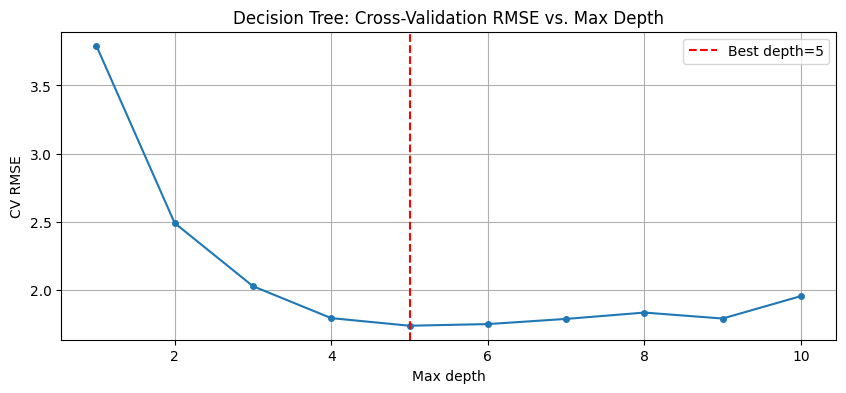


=== Decision Tree (depth=5) TEST PERFORMANCE ===
RMSE = 1.4996
MAE  = 1.1289
MAPE = 14.54%


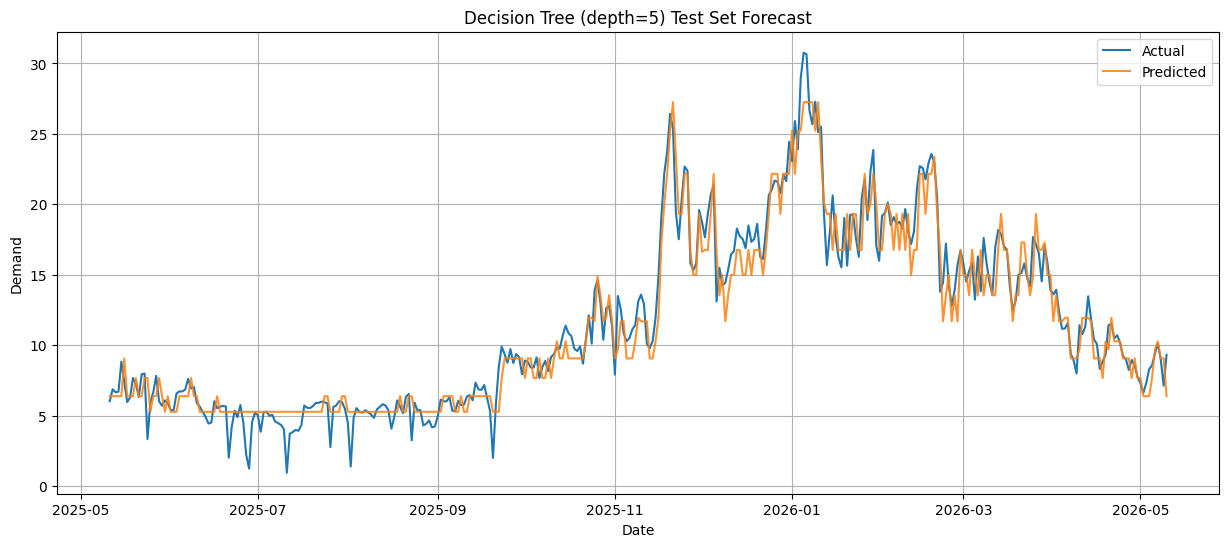

In [10]:
kf = KFold(n_splits=5, shuffle=True)
depths = range(1, 11)
dt_cv_rmse = []
for d in depths:
    scores = cross_val_score(
        DecisionTreeRegressor(max_depth=d, random_state=42),
        X_train_tree,
        y_train,
        cv=kf,
        scoring='neg_mean_squared_error'
    )
    dt_cv_rmse.append(np.sqrt(-scores.mean()))

best_depth = list(depths)[np.argmin(dt_cv_rmse)]
print(f'Best depth = {best_depth}  (CV RMSE = {min(dt_cv_rmse):.4f})')

plt.figure(figsize=(10, 4))
plt.plot(list(depths), dt_cv_rmse, marker='o', markersize=4)
plt.axvline(best_depth, color='red', linestyle='--', label=f'Best depth={best_depth}')
plt.xlabel('Max depth')
plt.ylabel('CV RMSE')
plt.title('Decision Tree: Cross-Validation RMSE vs. Max Depth')
plt.legend()
plt.grid(True)
plt.show()

dt_best = DecisionTreeRegressor(max_depth=best_depth, random_state=42)
dt_best.fit(X_train_tree, y_train)
y_pred_train_dt = dt_best.predict(X_train_tree)
y_pred_test_dt = dt_best.predict(X_test_tree)
predictions['Decision Tree'] = {'train': y_pred_train_dt, 'test': y_pred_test_dt}
print(f'\n=== Decision Tree (depth={best_depth}) TEST PERFORMANCE ===')
evaluate(y_test, y_pred_test_dt, 'Decision Tree')
plot_forecast(y_test, y_pred_test_dt, f'Decision Tree (depth={best_depth}) Test Set Forecast')

---
## Part 7: Random Forest

Ensemble of decision trees. `GridSearchCV` selects the best tree depth. Feature importances are shown.

Uses `FEATURE_COLS_TREE` (raw `dow` and `month`): importance is concentrated in 2 columns rather than spread across 17 dummies, giving a clearer signal.

Best RF max_depth = 5

=== Random Forest (depth=5) TEST PERFORMANCE ===
RMSE = 1.3967
MAE  = 1.0304
MAPE = 12.98%


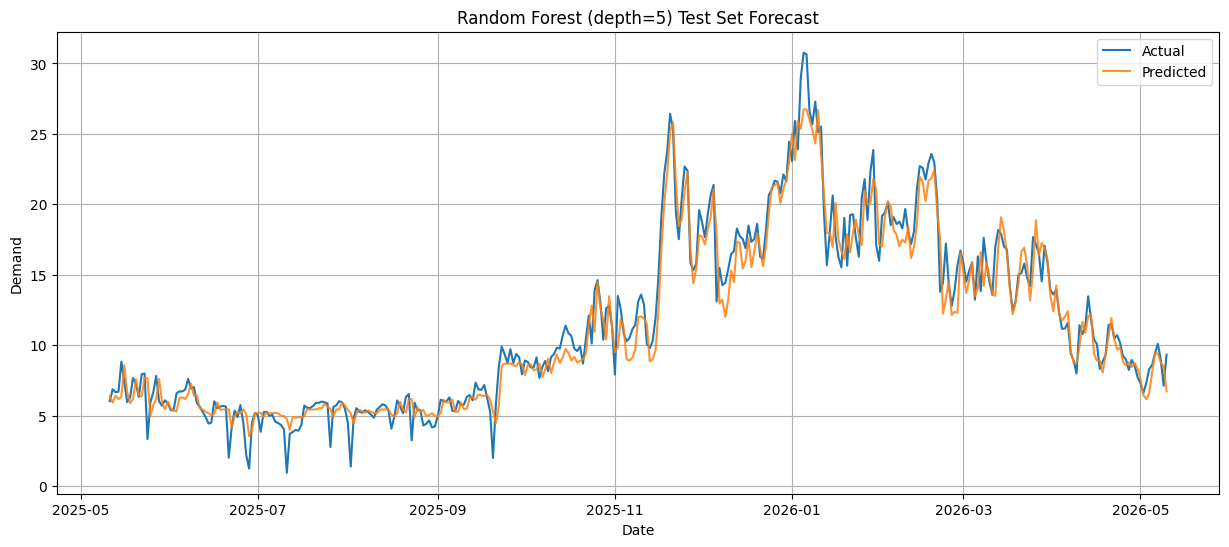

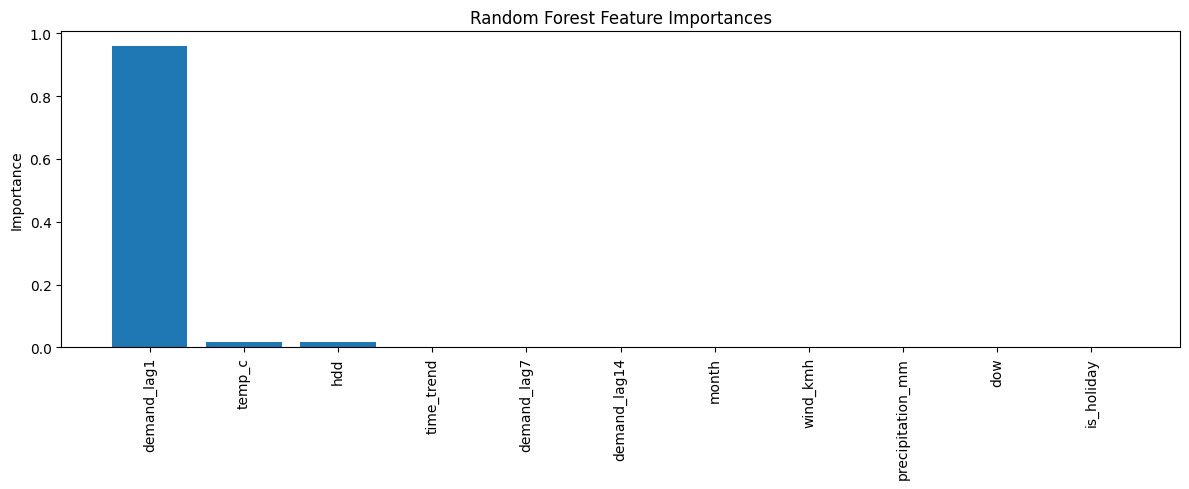

In [11]:
rf_param_grid = {'max_depth': range(3, 16)}
rf_gs = GridSearchCV(
    RandomForestRegressor(n_estimators=100, random_state=42),
    rf_param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)
rf_gs.fit(X_train_tree, y_train)
best_rf_depth = rf_gs.best_params_['max_depth']
print(f'Best RF max_depth = {best_rf_depth}')

rf_best = rf_gs.best_estimator_
y_pred_train_rf = rf_best.predict(X_train_tree)
y_pred_test_rf = rf_best.predict(X_test_tree)
predictions['Random Forest'] = {'train': y_pred_train_rf, 'test': y_pred_test_rf}
print(f'\n=== Random Forest (depth={best_rf_depth}) TEST PERFORMANCE ===')
evaluate(y_test, y_pred_test_rf, 'Random Forest')
plot_forecast(y_test, y_pred_test_rf, f'Random Forest (depth={best_rf_depth}) Test Set Forecast')

imp_df = pd.DataFrame({'Feature': FEATURE_COLS_TREE, 'Importance': rf_best.feature_importances_})
imp_df = imp_df.sort_values('Importance', ascending=False)
plt.figure(figsize=(12, 5))
plt.bar(imp_df['Feature'], imp_df['Importance'])
plt.xticks(rotation=90)
plt.ylabel('Importance')
plt.title('Random Forest Feature Importances')
plt.tight_layout()
plt.show()

---
## Part 8: Gradient Boosting

Sequential boosting ensemble. Two implementations are run and compared:

- **scikit-learn `GradientBoostingRegressor`**: depth and learning rate tuned via `GridSearchCV`
- **XGBoost `XGBRegressor`**: same grid, uses column subsampling and regularisation by default

Both use `FEATURE_COLS_TREE` (raw `dow` and `month`).

Best GB params: {'learning_rate': 0.05, 'max_depth': 3}

=== Gradient Boosting TEST PERFORMANCE ===
RMSE = 1.6104
MAE  = 1.3402
MAPE = 15.96%


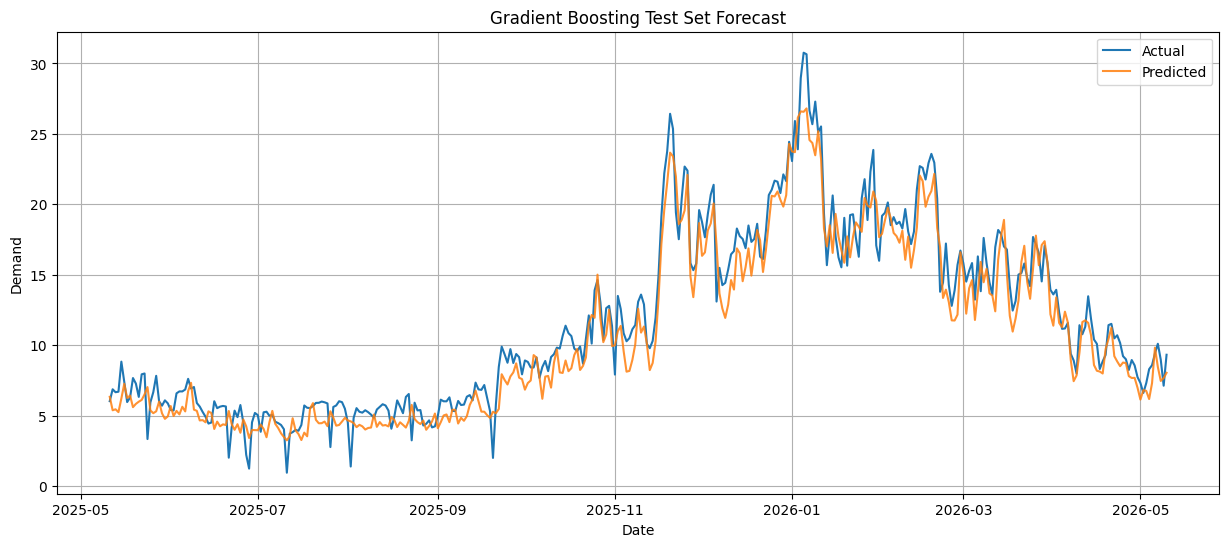

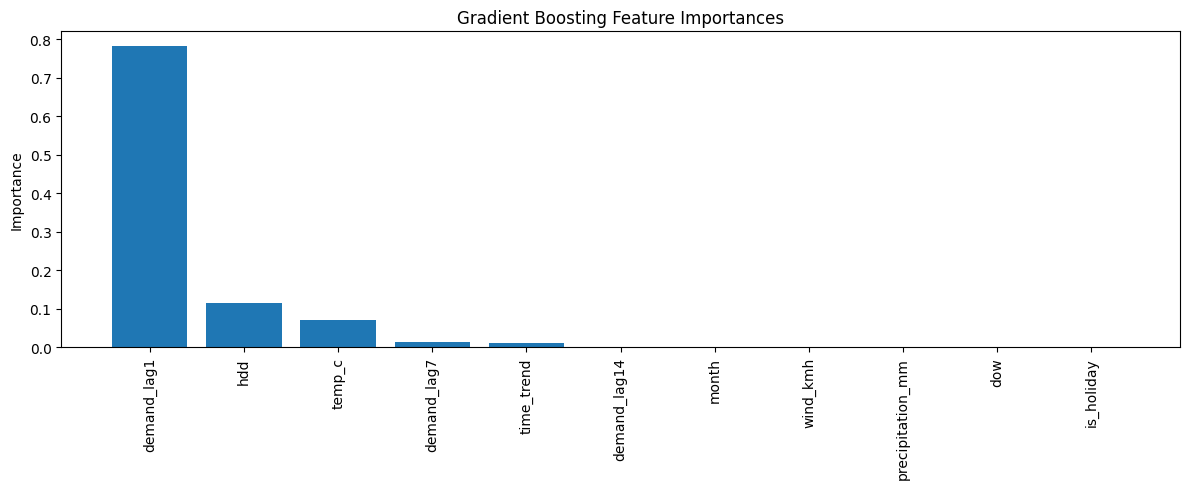


Best XGBoost params: {'learning_rate': 0.05, 'max_depth': 3}

=== XGBoost TEST PERFORMANCE ===
RMSE = 1.2193
MAE  = 0.8995
MAPE = 11.50%


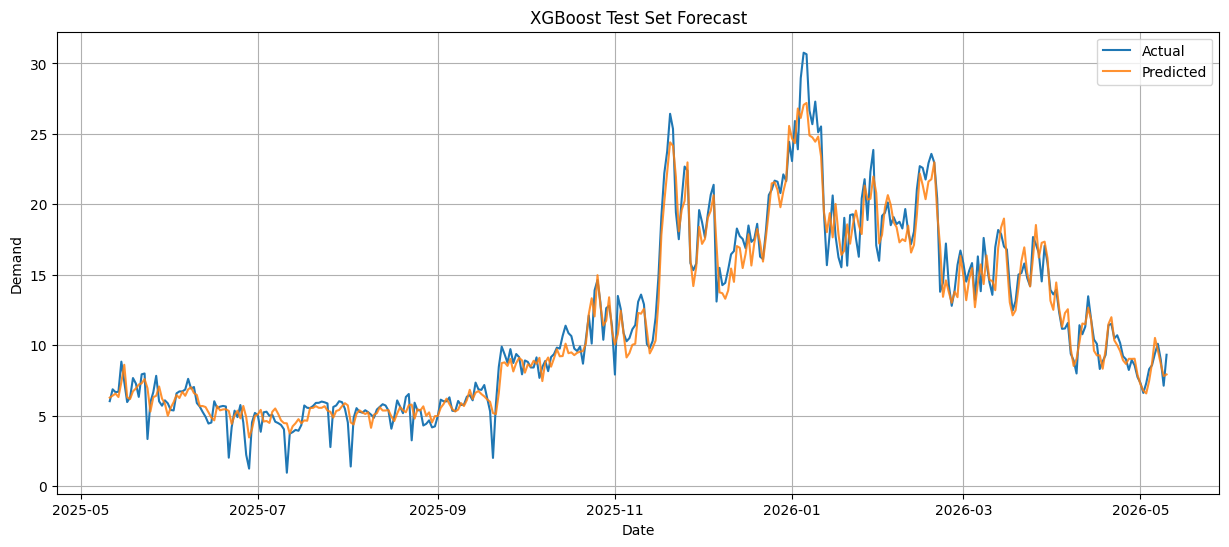

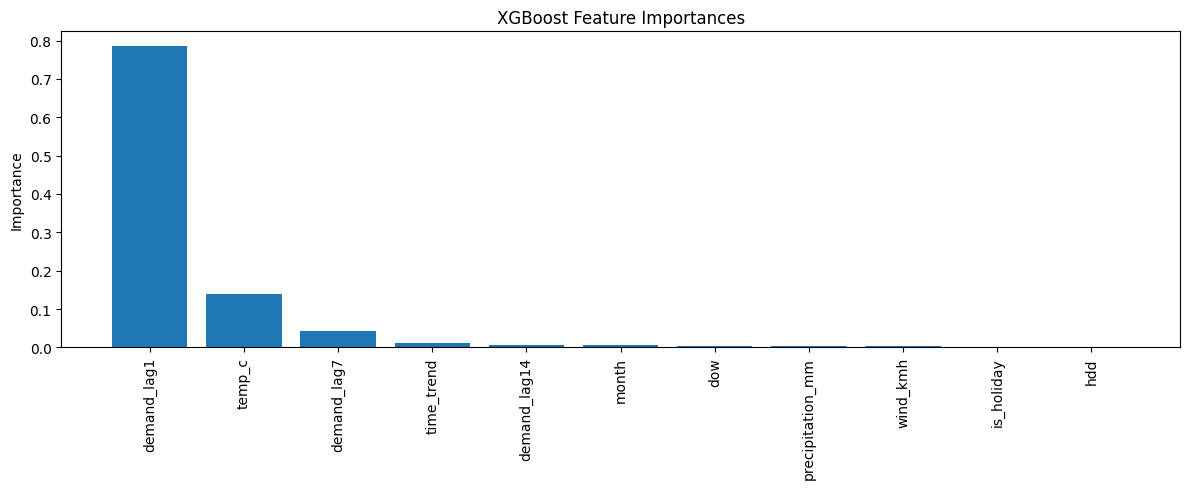

In [12]:
gb_param_grid = {'max_depth': [3, 4, 5], 'learning_rate': [0.05, 0.1, 0.2]}
gb_gs = GridSearchCV(
    GradientBoostingRegressor(n_estimators=200, random_state=42),
    gb_param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)
gb_gs.fit(X_train_tree, y_train)
print(f'Best GB params: {gb_gs.best_params_}')

gb_best = gb_gs.best_estimator_
y_pred_train_gb = gb_best.predict(X_train_tree)
y_pred_test_gb = gb_best.predict(X_test_tree)
predictions['Gradient Boosting'] = {'train': y_pred_train_gb, 'test': y_pred_test_gb}
print('\n=== Gradient Boosting TEST PERFORMANCE ===')
evaluate(y_test, y_pred_test_gb, 'Gradient Boosting')
plot_forecast(y_test, y_pred_test_gb, 'Gradient Boosting Test Set Forecast')

gb_imp_df = pd.DataFrame({'Feature': FEATURE_COLS_TREE, 'Importance': gb_best.feature_importances_})
gb_imp_df = gb_imp_df.sort_values('Importance', ascending=False)
plt.figure(figsize=(12, 5))
plt.bar(gb_imp_df['Feature'], gb_imp_df['Importance'])
plt.xticks(rotation=90)
plt.ylabel('Importance')
plt.title('Gradient Boosting Feature Importances')
plt.tight_layout()
plt.show()

xgb_gs = GridSearchCV(
    XGBRegressor(n_estimators=200, random_state=42,
                 tree_method='hist', verbosity=0),
    gb_param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)
xgb_gs.fit(X_train_tree, y_train)
print(f'\nBest XGBoost params: {xgb_gs.best_params_}')

xgb_best = xgb_gs.best_estimator_
y_pred_train_xgb = xgb_best.predict(X_train_tree)
y_pred_test_xgb = xgb_best.predict(X_test_tree)
predictions['XGBoost'] = {'train': y_pred_train_xgb, 'test': y_pred_test_xgb}
print('\n=== XGBoost TEST PERFORMANCE ===')
evaluate(y_test, y_pred_test_xgb, 'XGBoost')
plot_forecast(y_test, y_pred_test_xgb, 'XGBoost Test Set Forecast')

xgb_imp_df = pd.DataFrame({'Feature': FEATURE_COLS_TREE,
                           'Importance': xgb_best.feature_importances_})
xgb_imp_df = xgb_imp_df.sort_values('Importance', ascending=False)
plt.figure(figsize=(12, 5))
plt.bar(xgb_imp_df['Feature'], xgb_imp_df['Importance'])
plt.xticks(rotation=90)
plt.ylabel('Importance')
plt.title('XGBoost Feature Importances')
plt.tight_layout()
plt.show()

---
## Part 9: Neural Networks

Three sub-sections showing progressively more complex neural architectures.

- **Single-layer (linear) NN**: equivalent to OLS via gradient descent; serves as a baseline to verify the NN framework before adding depth.  
- **MLP**: 1-2 hidden layers with ReLU and early stopping. Epoch sensitivity is shown.  
- **LSTM/RNN**: recurrent architecture that processes the feature vector as a 1-step sequence.

In [13]:
scaler_nn = StandardScaler()
X_train_sc = scaler_nn.fit_transform(X_train)
X_test_sc = scaler_nn.transform(X_test)

### 9a: Single-Layer (Linear) Neural Network

=== Gradient Descent Linear Regressor TEST PERFORMANCE ===
RMSE = 1.3893
MAE  = 1.1423
MAPE = 13.53%


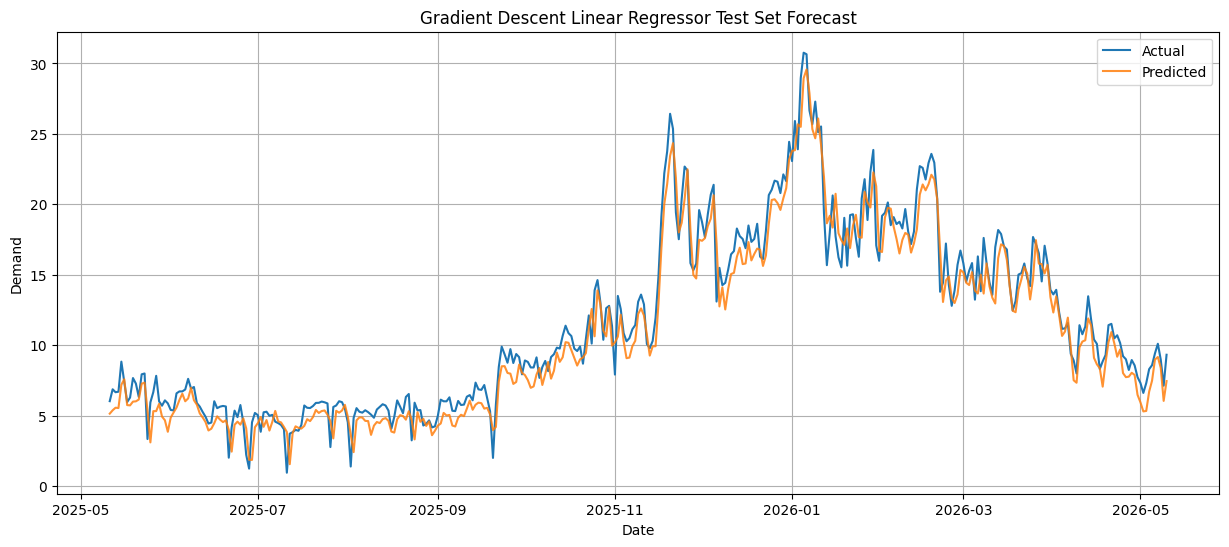

In [14]:
nn_linear = MLPRegressor(
    hidden_layer_sizes=(),
    activation='identity',
    max_iter=2000,
    random_state=42
)
nn_linear.fit(X_train_sc, y_train)
y_pred_train_nn1 = nn_linear.predict(X_train_sc)
y_pred_test_nn1 = nn_linear.predict(X_test_sc)
predictions['Gradient Descent Linear Regressor'] = {'train': y_pred_train_nn1, 'test': y_pred_test_nn1}
print('=== Gradient Descent Linear Regressor TEST PERFORMANCE ===')
evaluate(y_test, y_pred_test_nn1, 'Gradient Descent Linear Regressor')
plot_forecast(y_test, y_pred_test_nn1, 'Gradient Descent Linear Regressor Test Set Forecast')

### 9b: Multi-Layer Perceptron (MLP)

=== BEST MLP PARAMETERS ===
{'alpha': np.float64(1.0), 'hidden_layer_sizes': (32, 16), 'learning_rate_init': 0.05}
=== MLP TEST PERFORMANCE ===
RMSE = 2.1416
MAE  = 1.8124
MAPE = 25.37%


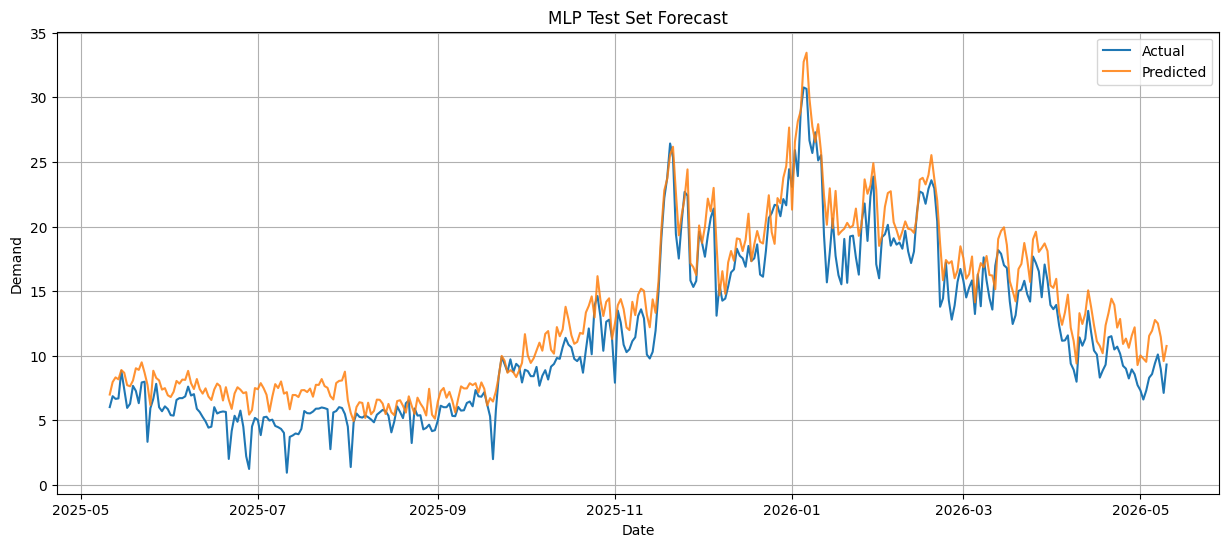

In [15]:
mlp_gs = GridSearchCV(
    estimator=MLPRegressor(
        activation='relu',
        early_stopping=True,
        validation_fraction=0.1,
        max_iter=500,
        random_state=42
    ),
    param_grid={'hidden_layer_sizes': [(16, ), (32, ), (32, 16), (64, 32), (32, 16, 8)],
                'alpha': np.logspace(-4, 0, num=5),
                'learning_rate_init': [0.001, 0.01, 0.05]},
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

mlp_gs.fit(X_train_sc, y_train)
y_pred_train_mlp = mlp_gs.predict(X_train_sc)
y_pred_test_mlp = mlp_gs.predict(X_test_sc)
print('=== BEST MLP PARAMETERS ===')
print(mlp_gs.best_params_)
predictions['MLP'] = {'train': y_pred_train_mlp, 'test': y_pred_test_mlp}
print('=== MLP TEST PERFORMANCE ===')
evaluate(y_test, y_pred_test_mlp, 'MLP')
plot_forecast(y_test, y_pred_test_mlp, 'MLP Test Set Forecast')

---
## Part 10: Model Comparison

All models evaluated on the same test set. The best model (lowest RMSE) will be used in the prescriptive section.

,RMSE,MAE,MAPE (%)
XGBoost,1.2193,0.8995,11.5042
Lasso,1.3617,1.0187,12.3201
OLS,1.3694,1.1141,13.2928
Ridge,1.3694,1.1143,13.2934
Gradient Descent Linear Regressor,1.3893,1.1423,13.5266
Random Forest,1.3967,1.0304,12.9757
SARIMAX,1.4377,1.1419,13.1564
Decision Tree,1.4996,1.1289,14.5384
Gradient Boosting,1.6104,1.3402,15.9592
kNN,1.6575,1.2280,14.7321



Best model by test RMSE: XGBoost


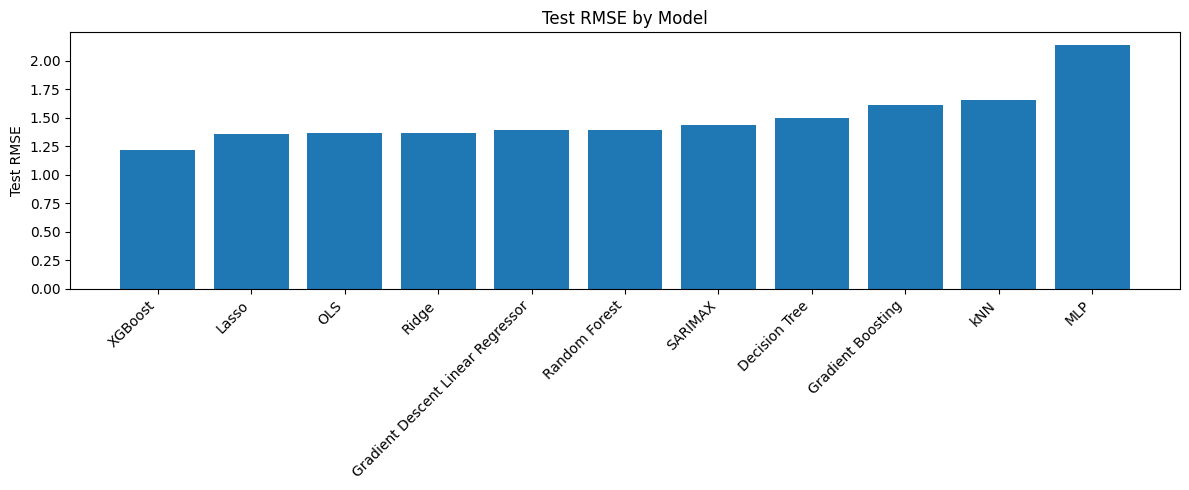


XGBoost error distribution plots


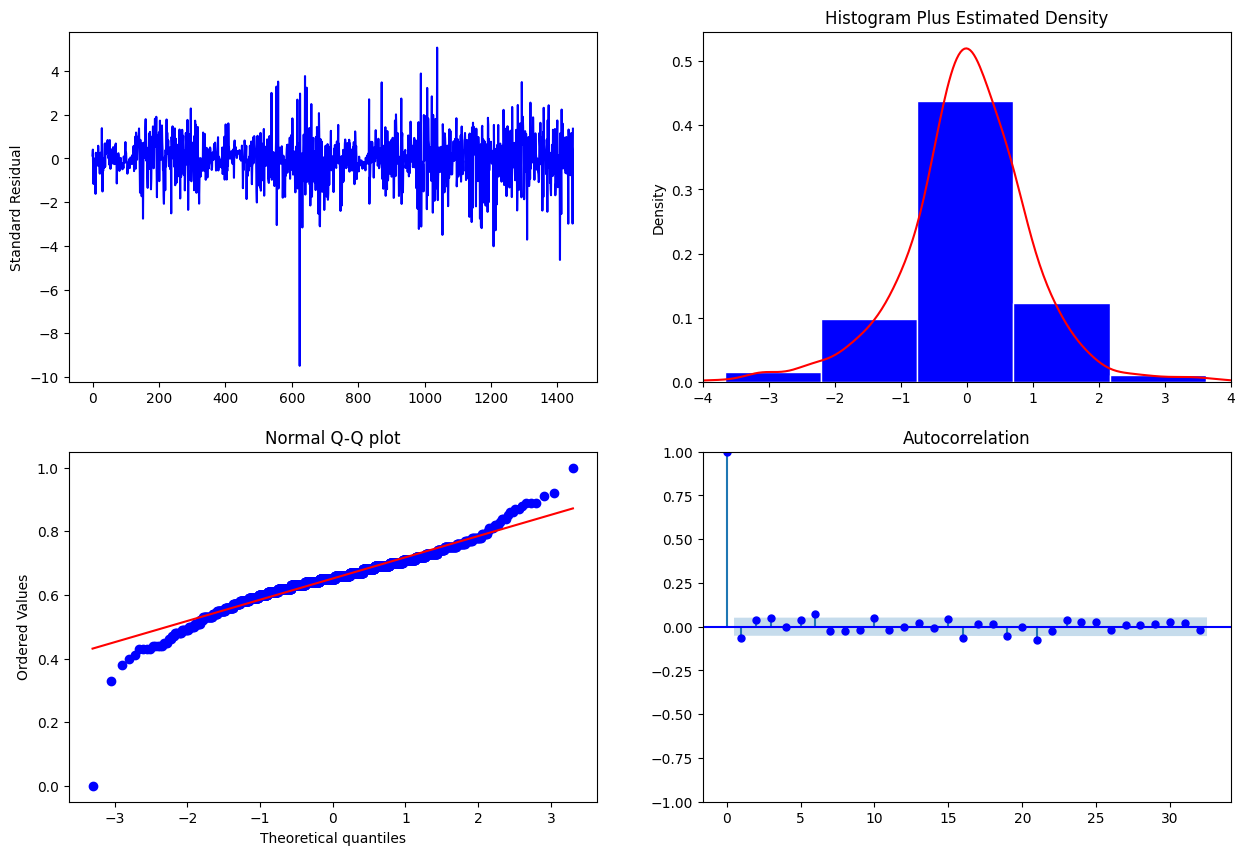

In [16]:
results_df = pd.DataFrame(results).T.round(4)
results_df = results_df.sort_values('RMSE')
display(results_df)

best_model_name = results_df.index[0]
print(f'\nBest model by test RMSE: {best_model_name}')

plt.figure(figsize=(12, 5))
plt.bar(results_df.index, results_df['RMSE'])
plt.xticks(rotation=45, ha='right')
plt.ylabel('Test RMSE')
plt.title('Test RMSE by Model')
plt.tight_layout()
plt.show()

print(f'\n{best_model_name} error distribution plots')
resid_best = y_train - predictions[best_model_name]['train']
bijan.eplot(resid_best)

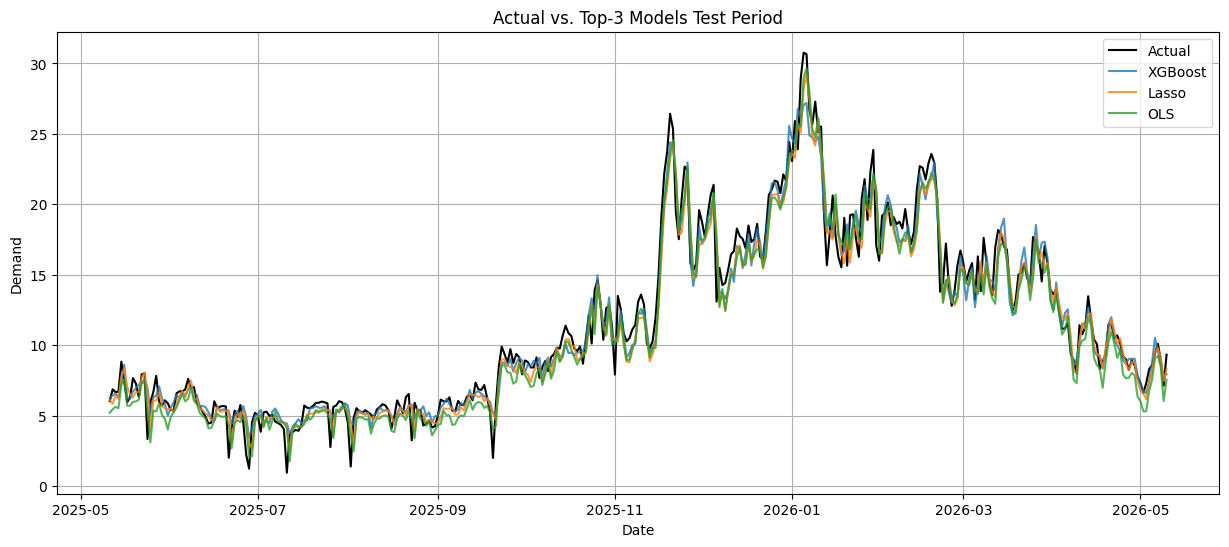

In [17]:
top3 = results_df.index[:3].tolist()
plt.figure(figsize=(15, 6))
plt.plot(test.index, y_test, label='Actual', linewidth=1.5, color='black')
for name in top3:
    plt.plot(test.index, predictions[name]['test'], label=name, alpha=0.8)
plt.xlabel('Date')
plt.ylabel('Demand')
plt.title('Actual vs. Top-3 Models Test Period')
plt.legend()
plt.grid(True)
plt.show()

### 10b: SHAP Feature Importance (Best Model)

SHAP (SHapley Additive exPlanations) assigns each feature a contribution to a specific prediction by averaging over all possible feature orderings. Unlike built-in impurity importance (measured on training data, biased toward high-cardinality features), SHAP values are theoretically grounded and additive: the sum of all SHAP values equals the prediction minus the base value.

Two plots are shown: a beeswarm summarising global importance across all test observations (each dot is one observation, colour encodes feature value), and a bar chart of mean absolute SHAP values for a compact ranking.

SHAP analysis for: XGBoost


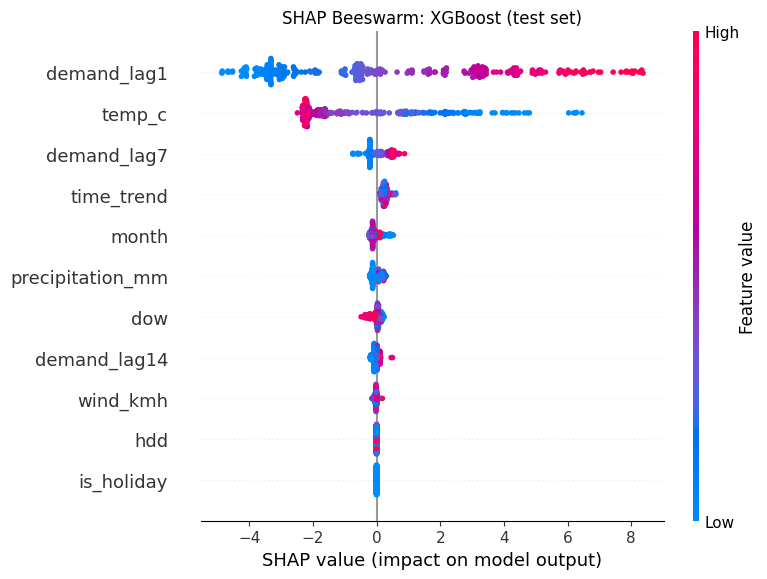

In [18]:
_tree_models = {
    'Decision Tree': (dt_best, X_test_tree, FEATURE_COLS_TREE),
    'Random Forest': (rf_best, X_test_tree, FEATURE_COLS_TREE),
    'Gradient Boosting': (gb_best, X_test_tree, FEATURE_COLS_TREE),
    'XGBoost': (xgb_best, X_test_tree, FEATURE_COLS_TREE),
}
_linear_models = {
    'OLS': (ols_fit, X_test, FEATURE_COLS),
    'Ridge': (ridge, X_test, FEATURE_COLS),
    'Lasso': (lasso, X_test, FEATURE_COLS),
    'Gradient Descent Linear Regressor': (nn_linear, X_test_sc, FEATURE_COLS),
    'MLP': (mlp_gs.best_estimator_, X_test_sc, FEATURE_COLS),
}

if best_model_name in _tree_models:
    model_obj, X_shap_arr, feat_names = _tree_models[best_model_name]
    X_shap = pd.DataFrame(X_shap_arr, columns=feat_names)
    explainer = shap.TreeExplainer(model_obj)
    shap_values = explainer(X_shap)
else:
    model_obj, X_shap_arr, feat_names = _linear_models[best_model_name]
    X_shap = pd.DataFrame(X_shap_arr, columns=feat_names)
    bg = shap.sample(X_shap, 100, random_state=42)

    if best_model_name == 'OLS':
        predict_fn = lambda x: ols_fit.predict(
            pd.DataFrame(x, columns=feat_names)
        ).values
    else:
        predict_fn = model_obj.predict

    explainer = shap.KernelExplainer(predict_fn, bg)
    shap_values = explainer(X_shap, silent=True)

print(f'SHAP analysis for: {best_model_name}')
shap.plots.beeswarm(shap_values, max_display=15, show=False)
plt.title(f'SHAP Beeswarm: {best_model_name} (test set)')
plt.tight_layout()
plt.show()

---
## Part 11: Prescriptive Analytics: Minimum Safety Stock

**Decision problem.** Each day we must set a safety stock level *S* for natural gas. If actual demand exceeds *S* there is a stockout; if *S* exceeds demand there is excess inventory. The constraint is:

$$P(\text{demand} > S) \leq 0.001 \quad (\text{99.9\% service level})$$

This maps to the **newsvendor problem** with critical fractile
$$\alpha = \frac{c_u}{c_u + c_o} = 0.999 \quad \Longrightarrow \quad c_u = 999,\ c_o = 1.$$

Four approaches are compared:

| | Method | Requires |
|---|---|---|
| 11a | ERM Separated (parametric) | Any prediction model + normal residuals |
| 11b | Newsvendor framing | Conceptual connection |
| 11c | SAA Separated (non-parametric) | Empirical residual distribution |
| 11d | Joint Estimation & Optimisation | Gurobi LP |

In [19]:
cu = 999
co = 1
alpha = cu / (cu + co)
z_alpha = stats.norm.ppf(alpha)
print(f'Critical fractile alpha = {alpha}')
print(f'Normal quantile z*  = {z_alpha:.4f}')

Critical fractile alpha = 0.999
Normal quantile z*  = 3.0902


### 11a: ERM / Separated Predict-then-Optimise (Parametric)

For each model: fit a normal distribution to training residuals and set
$$S^*(x) = \hat{y}(x) + z_{0.999} \cdot \hat{\sigma}$$
where $\hat{\sigma}$ is the standard deviation of training residuals. Performance is measured by average newsvendor cost on the test set.

ERM prescriptive results (all models):


,Avg S*,Stockout rate,Avg excess,Avg newsvendor cost
Gradient Descent Linear Regressor,15.0495,0.0000,3.4611,3.4611
Ridge,15.0773,0.0000,3.4889,3.4889
OLS,15.0776,0.0000,3.4892,3.4892
Lasso,15.5728,0.0000,3.9844,3.9844
Decision Tree,15.7235,0.0000,4.1351,4.1351
Random Forest,15.0995,0.0082,3.5122,4.6098
MLP,16.6872,0.0000,5.0988,5.0988
SARIMAX,14.7222,0.0027,3.1359,5.2039
XGBoost,14.2845,0.0137,2.7018,8.4573
kNN,16.1561,0.0110,4.5765,13.3175


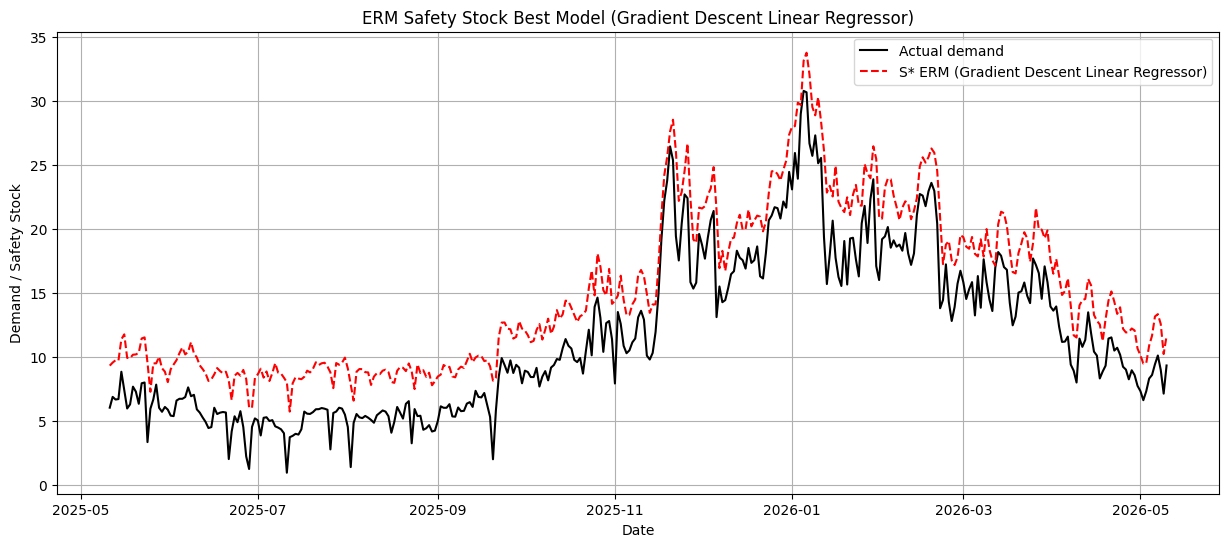

In [20]:
pres_results = {}

for name, preds in predictions.items():
    resid_train = y_train - preds['train']
    sigma_r = np.std(resid_train, ddof=1)
    S_test = np.maximum(preds['test'] + z_alpha * sigma_r, 0)

    stockout_rate = np.mean(y_test > S_test)
    avg_S = np.mean(S_test)
    avg_excess = np.mean(np.maximum(S_test - y_test, 0))
    avg_newsvendor_cost = average_cost(S_test, y_test, cu=cu, co=co)

    pres_results[name] = {
        'Method': 'ERM (normal)',
        'Avg S*': avg_S,
        'Stockout rate': stockout_rate,
        'Avg excess stock': avg_excess,
        'Avg newsvendor cost': avg_newsvendor_cost,
        'S_test': S_test
    }

print('ERM prescriptive results (all models):')
erm_summary = pd.DataFrame({
    k: {
        'Avg S*': v['Avg S*'],
        'Stockout rate': v['Stockout rate'],
        'Avg excess': v['Avg excess stock'],
        'Avg newsvendor cost': v['Avg newsvendor cost']
    }
    for k, v in pres_results.items()
}).T.round(4).sort_values('Avg newsvendor cost')
display(erm_summary)

best_erm = erm_summary.index[0]
plt.figure(figsize=(15, 6))
plt.plot(test.index, y_test, label='Actual demand', color='black')
plt.plot(test.index, pres_results[best_erm]['S_test'], label=f'S* ERM ({best_erm})', color='red', linestyle='--')
plt.xlabel('Date')
plt.ylabel('Demand / Safety Stock')
plt.title(f'ERM Safety Stock Best Model ({best_erm})')
plt.legend()
plt.grid(True)
plt.show()

### 11b: Newsvendor Framing

The ERM formula $S^* = \hat{y} + z_{0.999}\hat{\sigma}$ is the **parametric newsvendor solution**: under normality it gives the 0.999-conditional quantile of demand given features. The critical fractile $\alpha = c_u/(c_u + c_o)$ pins the service level directly to the cost ratio.

A non-parametric alternative (Part 11c) replaces the normal quantile with the empirical quantile of training residuals, removing the distributional assumption.

### 11c: Sample Average Approximation (SAA)

For each test day:
$$S^*_{\text{SAA}}(x) = \hat{y}(x) + Q_{0.999}(\hat{\varepsilon}_{\text{train}})$$
where $Q_{0.999}$ is the discrete empirical quantile of training residuals defined as $\min\{q : \hat{F}(q) \geq \alpha\}$ (the same criterion used in the newsvendor optimality condition). No distributional assumption is needed.

In [21]:
saa_results = {}

for name, preds in predictions.items():
    resid_train = y_train - preds['train']
    q_shift = empirical_quantile_min_cdf(resid_train, alpha)
    S_test = np.maximum(preds['test'] + q_shift, 0)

    stockout_rate = np.mean(y_test > S_test)
    avg_S = np.mean(S_test)
    avg_excess = np.mean(np.maximum(S_test - y_test, 0))
    avg_newsvendor_cost = average_cost(S_test, y_test, cu=cu, co=co)

    saa_results[name] = {
        'Method': 'SAA (empirical)',
        'Avg S*': avg_S,
        'Stockout rate': stockout_rate,
        'Avg excess stock': avg_excess,
        'Avg newsvendor cost': avg_newsvendor_cost,
        'S_test': S_test
    }

print('SAA prescriptive results (all models):')
saa_summary = pd.DataFrame({
    k: {
        'Avg S*': v['Avg S*'],
        'Stockout rate': v['Stockout rate'],
        'Avg excess': v['Avg excess stock'],
        'Avg newsvendor cost': v['Avg newsvendor cost']
    }
    for k, v in saa_results.items()
}).T.round(4).sort_values('Avg newsvendor cost')
display(saa_summary)

SAA prescriptive results (all models):


,Avg S*,Stockout rate,Avg excess,Avg newsvendor cost
XGBoost,15.0283,0.0027,3.4401,3.6777
Random Forest,16.0395,0.0000,4.4511,4.4511
Gradient Descent Linear Regressor,16.3200,0.0000,4.7316,4.7316
Ridge,16.3730,0.0000,4.7846,4.7846
OLS,16.3736,0.0000,4.7852,4.7852
Decision Tree,16.4560,0.0000,4.8676,4.8676
SARIMAX,16.6890,0.0000,5.1006,5.1006
kNN,17.1609,0.0055,5.5727,5.7694
MLP,17.5092,0.0000,5.9208,5.9208
Lasso,17.7439,0.0000,6.1555,6.1555


### 11d: Joint Estimation and Optimisation (Linear Rule via Gurobi LP)

Rather than separating prediction and optimisation, we directly find the **linear rule** $S^*(x) = q_0 + \beta^\top x$ that minimises average newsvendor cost on the training set:

$$\min_{q_0,\,\beta,\,Z^+,\,Z^-} \; \frac{1}{n}\sum_{i=1}^n \left[ c_u Z^+_i + c_o Z^-_i \right]$$
$$\text{s.t.}\quad Z^+_i \geq d_i - (q_0 + \beta^\top x_i), \quad Z^-_i \geq (q_0 + \beta^\top x_i) - d_i, \quad Z^+_i, Z^-_i \geq 0$$

This is an **LP** because the newsvendor cost is piecewise linear and the decision rule is linear — no differentiation through the optimisation oracle is needed. This is the tractable special case of the SPO+ framework (Elmachtoub & Grigas, 2022); SPO+ generalises it to nonlinear rules but requires a differentiable surrogate loss.

Restricted license - for non-production use only - expires 2027-11-29
Average newsvendor cost on training set (n=900): 2.6148
Average newsvendor cost on test set    : 17.5269
Test stockout rate                     : 0.0384
Avg S* (test)                          : 13.7240
Avg excess stock                       : 2.1510


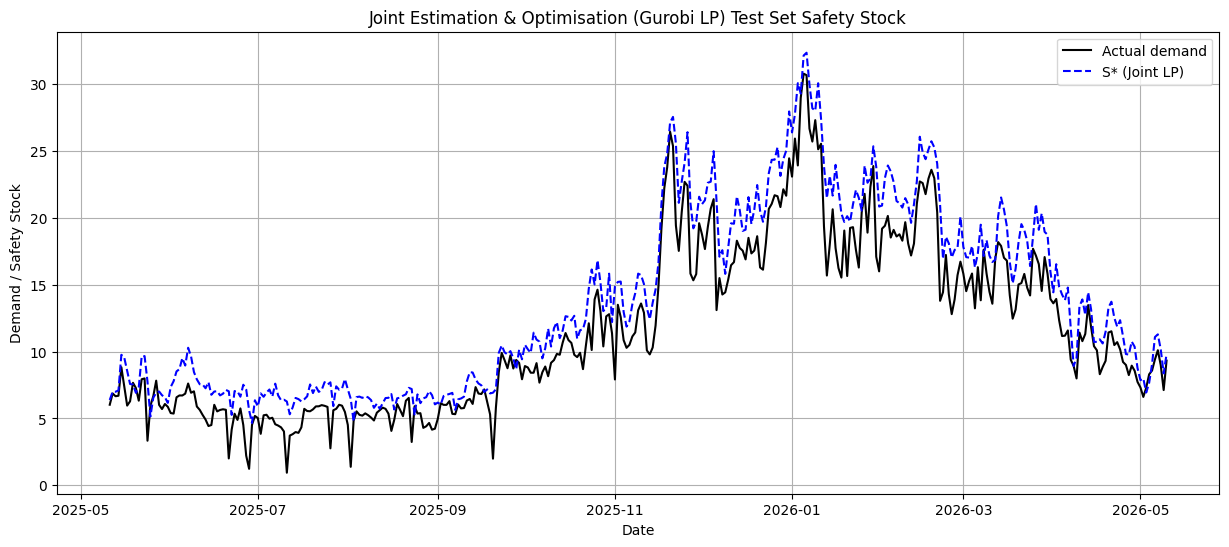

In [22]:
rng = np.random.default_rng(42)
lp_idx = rng.choice(len(y_train), size=900, replace=False)
lp_idx.sort()
X_lp = X_train[lp_idx]
y_lp = y_train[lp_idx]

n_train_p = len(y_lp)
n_feat_p = X_lp.shape[1]

lp = Model('JointNewsvendor')
lp.setParam('OutputFlag', 0)

Z_pos = lp.addVars(n_train_p, name='Underage', lb=0)
Z_neg = lp.addVars(n_train_p, name='Overage', lb=0)
beta = lp.addVars(n_feat_p, name='beta', lb=float('-inf'), vtype=GRB.CONTINUOUS)
q0 = lp.addVar(name='q0', lb=float('-inf'), vtype=GRB.CONTINUOUS)

lp.addConstrs(
    (Z_pos[i] >= y_lp[i] - (q0 + quicksum(X_lp[i, j] * beta[j] for j in range(n_feat_p)))
     for i in range(n_train_p)), name='Underage')
lp.addConstrs(
    (Z_neg[i] >= (q0 + quicksum(X_lp[i, j] * beta[j] for j in range(n_feat_p))) - y_lp[i]
     for i in range(n_train_p)), name='Overage')

lp.setObjective(
    (1 / n_train_p) * quicksum(cu * Z_pos[i] + co * Z_neg[i] for i in range(n_train_p)),
    GRB.MINIMIZE)

lp.optimize()

beta_vals = np.array([beta[j].X for j in range(n_feat_p)])
q0_val = q0.X

S_train_lp = np.maximum(q0_val + X_lp @ beta_vals, 0)
S_test_lp = np.maximum(q0_val + X_test @ beta_vals, 0)

lp_train_cost = average_cost(S_train_lp, y_lp, cu=cu, co=co)
lp_test_cost = average_cost(S_test_lp, y_test, cu=cu, co=co)
lp_stockout = np.mean(y_test > S_test_lp)
lp_avg_S = np.mean(S_test_lp)
lp_excess = np.mean(np.maximum(S_test_lp - y_test, 0))

print(f'Average newsvendor cost on training set (n={n_train_p}): {lp_train_cost:.4f}')
print(f'Average newsvendor cost on test set    : {lp_test_cost:.4f}')
print(f'Test stockout rate                     : {lp_stockout:.4f}')
print(f'Avg S* (test)                          : {lp_avg_S:.4f}')
print(f'Avg excess stock                       : {lp_excess:.4f}')

plt.figure(figsize=(15, 6))
plt.plot(test.index, y_test, label='Actual demand', color='black')
plt.plot(test.index, S_test_lp, label='S* (Joint LP)', color='blue', linestyle='--')
plt.xlabel('Date')
plt.ylabel('Demand / Safety Stock')
plt.title('Joint Estimation & Optimisation (Gurobi LP) Test Set Safety Stock')
plt.legend()
plt.grid(True)
plt.show()

### 11e: Prescriptive Comparison

Best ERM (parametric) and SAA (non-parametric) rows per prediction model, plus the joint LP rule. Ranked by average excess stock subject to stockout rate ≤ 0.001.

In [23]:
rows = []
for name in predictions:
    for method_label, store in [('ERM (normal)', pres_results), ('SAA (empirical)', saa_results)]:
        rows.append({
            'Prediction model': name,
            'Framework': method_label,
            'Avg S*': store[name]['Avg S*'],
            'Stockout rate': store[name]['Stockout rate'],
            'Avg excess stock': store[name]['Avg excess stock'],
            'Avg newsvendor cost': store[name]['Avg newsvendor cost']
        })

rows.append({
    'Prediction model': 'Joint LP (Gurobi)',
    'Framework': 'Joint EO (linear rule)',
    'Avg S*': lp_avg_S,
    'Stockout rate': lp_stockout,
    'Avg excess stock': lp_excess,
    'Avg newsvendor cost': lp_test_cost
})

pres_df = pd.DataFrame(rows).round(4)
feasible = pres_df[pres_df['Stockout rate'] <= 0.001].sort_values('Avg newsvendor cost')
infeasible = pres_df[pres_df['Stockout rate'] > 0.001].sort_values('Stockout rate')

print('=== FEASIBLE (stockout rate <= 0.001) ===')
display(feasible.reset_index(drop=True))

print('\n=== INFEASIBLE (stockout rate > 0.001) ===')
display(infeasible.reset_index(drop=True))

=== FEASIBLE (stockout rate <= 0.001) ===


,Prediction model,Framework,Avg S*,Stockout rate,Avg excess stock,Avg newsvendor cost
0,Gradient Descent Linear Regressor,ERM (normal),15.0495,0.0,3.4611,3.4611
1,Ridge,ERM (normal),15.0773,0.0,3.4889,3.4889
2,OLS,ERM (normal),15.0776,0.0,3.4892,3.4892
3,Lasso,ERM (normal),15.5728,0.0,3.9844,3.9844
4,Decision Tree,ERM (normal),15.7235,0.0,4.1351,4.1351
5,Random Forest,SAA (empirical),16.0395,0.0,4.4511,4.4511
6,Gradient Descent Linear Regressor,SAA (empirical),16.3200,0.0,4.7316,4.7316
7,Ridge,SAA (empirical),16.3730,0.0,4.7846,4.7846
8,OLS,SAA (empirical),16.3736,0.0,4.7852,4.7852
9,Decision Tree,SAA (empirical),16.4560,0.0,4.8676,4.8676



=== INFEASIBLE (stockout rate > 0.001) ===


,Prediction model,Framework,Avg S*,Stockout rate,Avg excess stock,Avg newsvendor cost
0,SARIMAX,ERM (normal),14.7222,0.0027,3.1359,5.2039
1,XGBoost,SAA (empirical),15.0283,0.0027,3.4401,3.6777
2,kNN,SAA (empirical),17.1609,0.0055,5.5727,5.7694
3,Random Forest,ERM (normal),15.0995,0.0082,3.5122,4.6098
4,kNN,ERM (normal),16.1561,0.0110,4.5765,13.3175
5,Gradient Boosting,SAA (empirical),14.4190,0.0137,2.8360,8.2584
6,XGBoost,ERM (normal),14.2845,0.0137,2.7018,8.4573
7,Joint LP (Gurobi),Joint EO (linear rule),13.7240,0.0384,2.1510,17.5269
8,Gradient Boosting,ERM (normal),13.5054,0.0411,1.9457,30.6366


# REPLACE LATER BY THE BEST MODEL

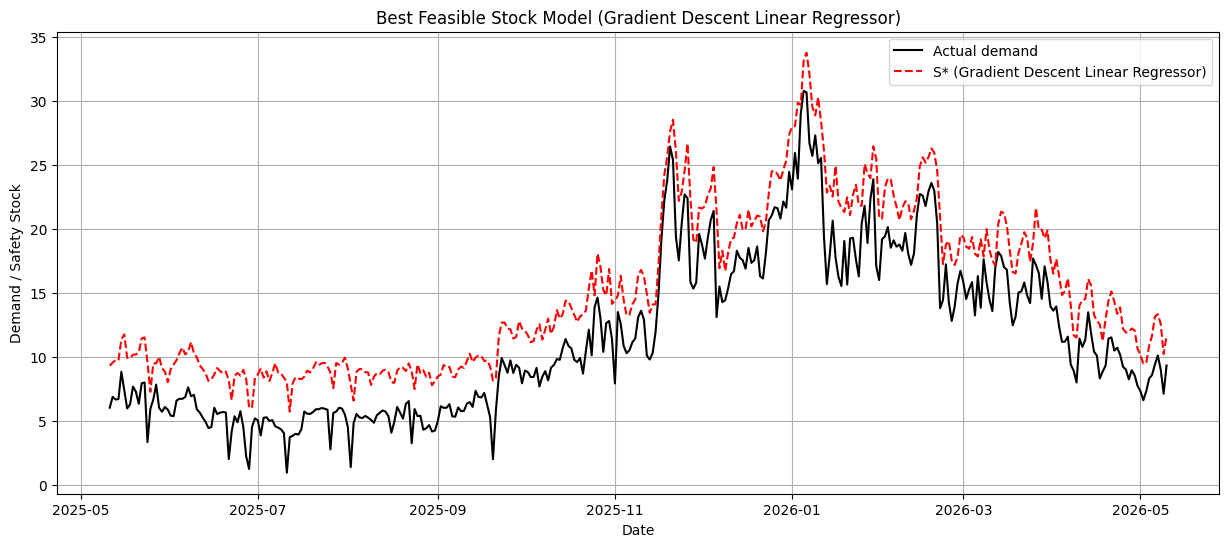

In [24]:
best_feasible = feasible.iloc[0, 0]
plt.figure(figsize=(15, 6))
plt.plot(test.index, y_test, label='Actual demand', color='black')
plt.plot(test.index, pres_results[best_feasible]['S_test'], label=f'S* ({best_feasible})', color='red', linestyle='--')
plt.xlabel('Date')
plt.ylabel('Demand / Safety Stock')
plt.title(f'Best Feasible Stock Model ({best_feasible})')
plt.legend()
plt.grid(True)
plt.show()